In [1]:
import numpy as np
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
import seaborn as sns

from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

In [2]:
roc_curve = RocCurveDisplay.from_estimator

### Support Vector Classifier

<Axes: ylabel='Density'>

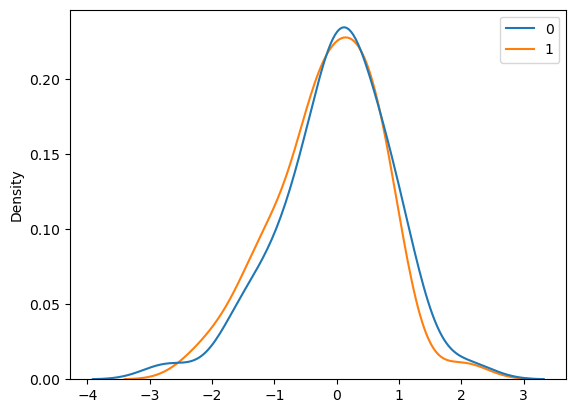

In [3]:
rng = np.random.default_rng(1)
X = rng.standard_normal((50, 2)) #create 50 x 2 martrix with 2 features

sns.kdeplot(X)

In [4]:
y = np.array([-1] * 25 + [1] * 25)
y

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [5]:
X[y==1]

array([[ 3.20848305e-01, -8.18230227e-01],
       [ 7.31652284e-01, -5.01440018e-01],
       [ 8.79160618e-01, -1.07178742e+00],
       [ 9.14467203e-01, -2.00634546e-02],
       [-1.24874889e+00, -3.13899472e-01],
       [ 5.41022788e-02,  2.72791339e-01],
       [-9.82188125e-01, -1.10737305e+00],
       [ 1.99584533e-01, -4.66749617e-01],
       [ 2.35505612e-01,  7.59519522e-01],
       [-1.64878737e+00,  2.54388117e-01],
       [ 1.22464697e+00, -2.97526844e-01],
       [-8.10814583e-01,  7.52243827e-01],
       [ 2.53446516e-01,  8.95883071e-01],
       [-3.45215710e-01, -1.48181827e+00],
       [-1.10010765e-01, -4.45828153e-01],
       [ 7.75323822e-01,  1.93632848e-01],
       [-1.63084923e+00, -1.19516308e+00],
       [ 8.83789037e-01,  6.79765017e-01],
       [-6.40243366e-01, -1.04879657e-03],
       [ 4.45573554e-01,  4.68404336e-01],
       [ 8.76242196e-01,  2.56485627e-01],
       [-9.48283390e-02, -2.58848065e-01],
       [ 1.05574280e+00, -2.25085428e+00],
       [-1.

In [6]:
X[y==1] += 1 #move one class a little bit two make some separation
X[y==1]

array([[ 1.3208483 ,  0.18176977],
       [ 1.73165228,  0.49855998],
       [ 1.87916062, -0.07178742],
       [ 1.9144672 ,  0.97993655],
       [-0.24874889,  0.68610053],
       [ 1.05410228,  1.27279134],
       [ 0.01781188, -0.10737305],
       [ 1.19958453,  0.53325038],
       [ 1.23550561,  1.75951952],
       [-0.64878737,  1.25438812],
       [ 2.22464697,  0.70247316],
       [ 0.18918542,  1.75224383],
       [ 1.25344652,  1.89588307],
       [ 0.65478429, -0.48181827],
       [ 0.88998924,  0.55417185],
       [ 1.77532382,  1.19363285],
       [-0.63084923, -0.19516308],
       [ 1.88378904,  1.67976502],
       [ 0.35975663,  0.9989512 ],
       [ 1.44557355,  1.46840434],
       [ 1.8762422 ,  1.25648563],
       [ 0.90517166,  0.74115194],
       [ 2.0557428 , -1.25085428],
       [ 0.86134467,  1.0330001 ],
       [-0.42534896,  1.33281361]])

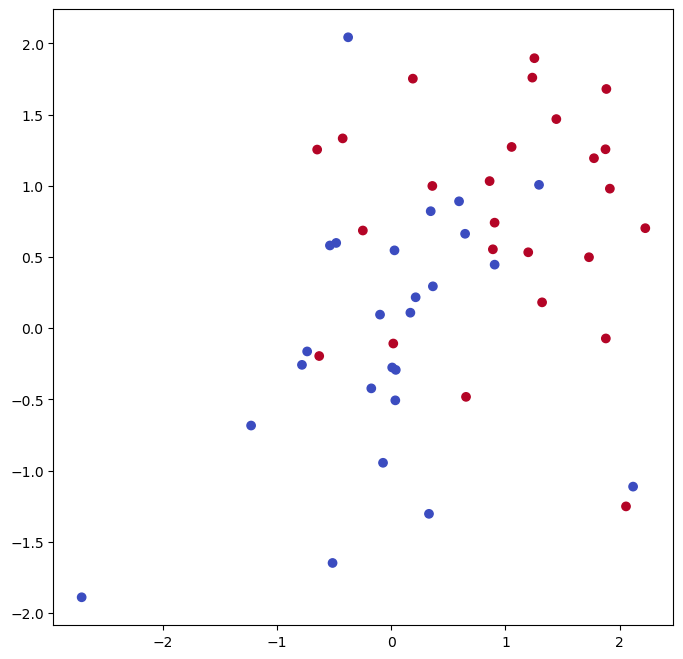

In [7]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(X[:, 0],
           X[:, 1],
           c=y,
           cmap=cm.coolwarm)

In [8]:
svm_linear = SVC(C=10, kernel="linear")
svm_linear.fit(X, y)

SVC(C=10, kernel='linear')

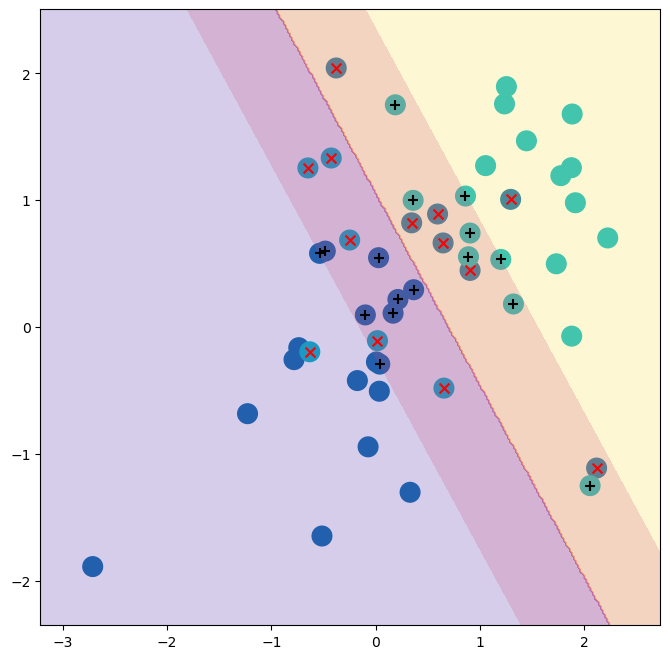

In [9]:
fig, ax = subplots(figsize=(8, 8))
plot_svm(X,
         y,
         svm_linear,
         ax=ax)

 The support vectors are marked with "+" and the remaining observations are plotted as circles

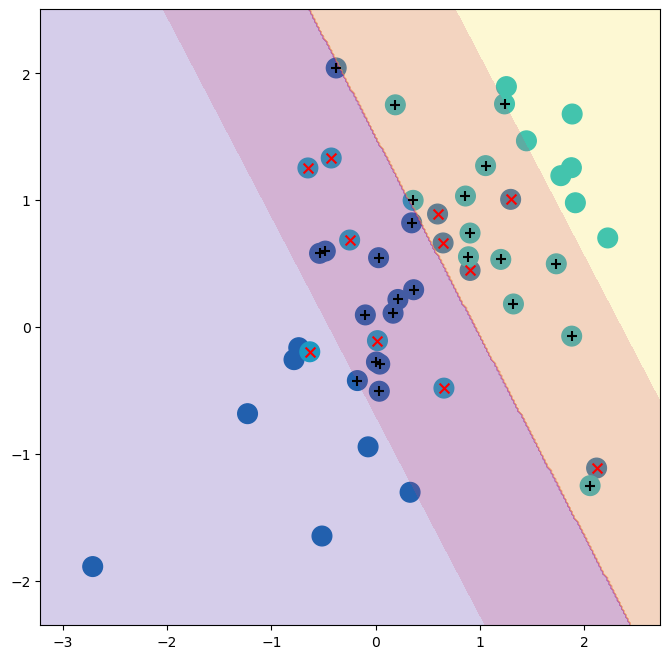

In [10]:
svm_linear_small = SVC(C=0.1, kernel="linear")
svm_linear_small.fit(X, y)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X,
         y,
         svm_linear_small,
         ax=ax)

Here penalty `C` is small, so model can misclassify data points without big penaltu for it which allows to have bigger margin and more support vectors

In [11]:
svm_linear.coef_

array([[1.17303943, 0.77348227]])

In [12]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

grid = skm.GridSearchCV(estimator=svm_linear,
                        param_grid={"C": [0.001, 0.01, 0.1, 1, 5, 10, 100]},
                        refit=True,
                        cv=kfold,
                        scoring="accuracy")

grid.fit(X, y)
grid.best_params_

{'C': 1}

In [13]:
grid.cv_results_["mean_test_score"]

array([0.46, 0.46, 0.72, 0.74, 0.74, 0.74, 0.74])

In [14]:
X_test = rng.standard_normal((20, 2))
y_test = np.array([-1] * 10 + [1] * 10)
X_test[y_test==1] += 1

In [15]:
best_ = grid.best_estimator_
y_test_hat = best_.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,-1,1
Predicted,,
-1,8,4
1,2,6


In [16]:
svm_ = SVC(C=0.001, kernel="linear").fit(X, y)
y_test_hat = svm_.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,-1,1
Predicted,,
-1,2,0
1,8,10


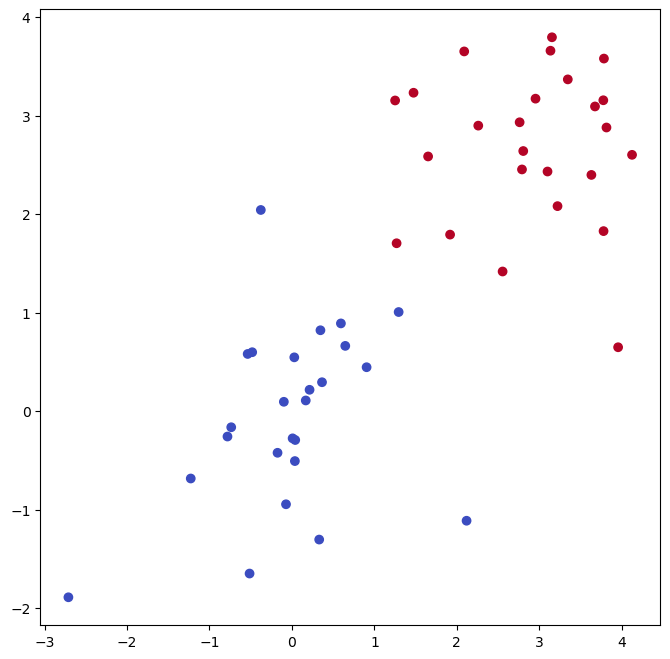

In [17]:
X[y==1] += 1.9
fig, ax = subplots(figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=y, cmap=cm.coolwarm)

In [18]:
svm_ = SVC(C=1e5, kernel='linear').fit(X, y)
y_hat = svm_.predict(X)
confusion_table(y_hat, y)

Truth,-1,1
Predicted,,
-1,25,0
1,0,25


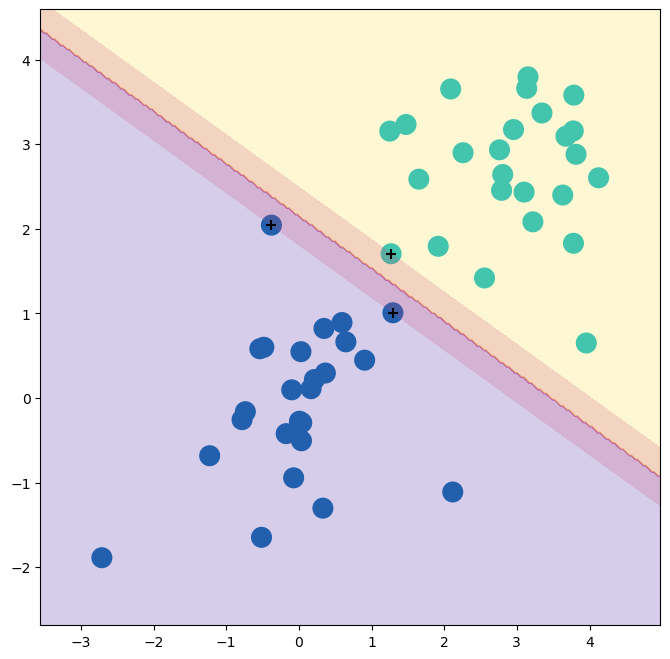

In [19]:
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
y,
svm_,
ax=ax)

In fact, the large value of C also means that these three support points
are on the margin, and define it. One may wonder how good the classifier
could be on test data that depends on only three data points!

In [20]:
svm_ = SVC(C=0.1, kernel='linear').fit(X, y)
y_hat = svm_.predict(X)
confusion_table(y_hat, y)

Truth,-1,1
Predicted,,
-1,25,0
1,0,25


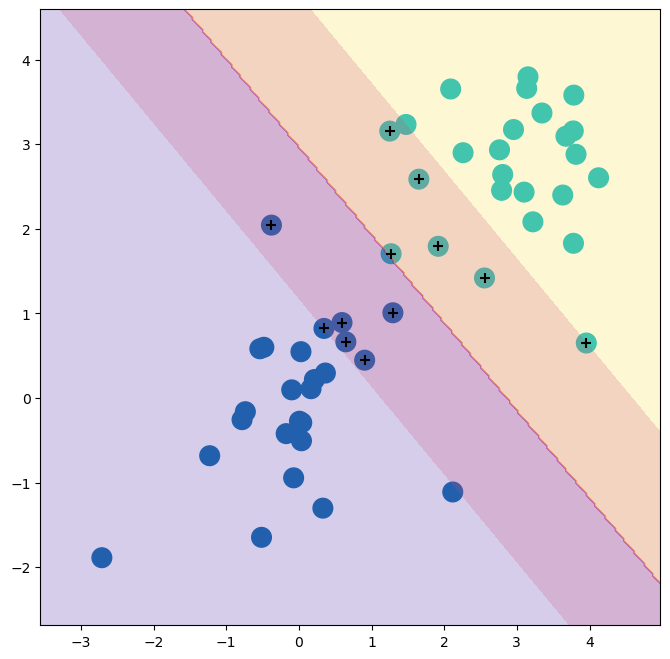

In [21]:
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
y,
svm_,
ax=ax)

### Support Vector Machine

In [22]:
X = rng.standard_normal((200, 2))
X[:100] += 2
X[100:150] -= 2
y = np.array([-1] * 150 + [1] * 50)

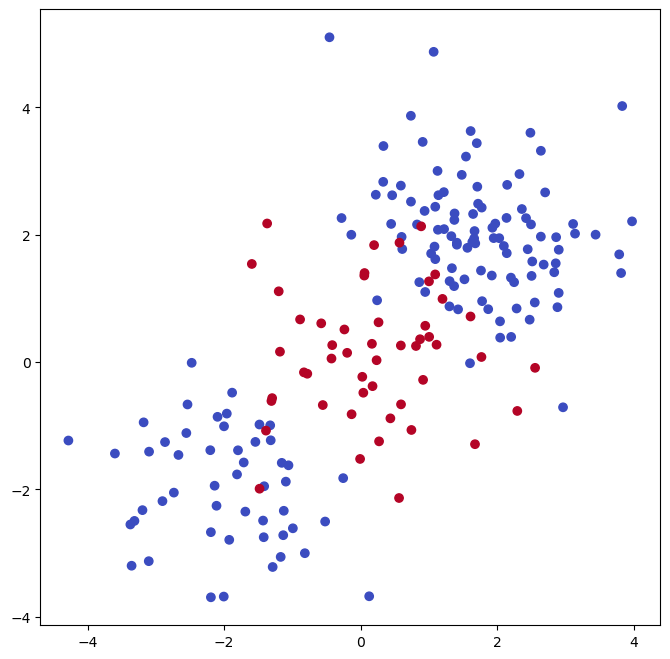

In [23]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(X[:, 0],
           X[:, 1],
           c=y,
           cmap=cm.coolwarm)

In [25]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.5, random_state=0)
svm_rbf = SVC(kernel="rbf", gamma=1, C=1)
svm_rbf.fit(X_train, y_train)

SVC(C=1, gamma=1)

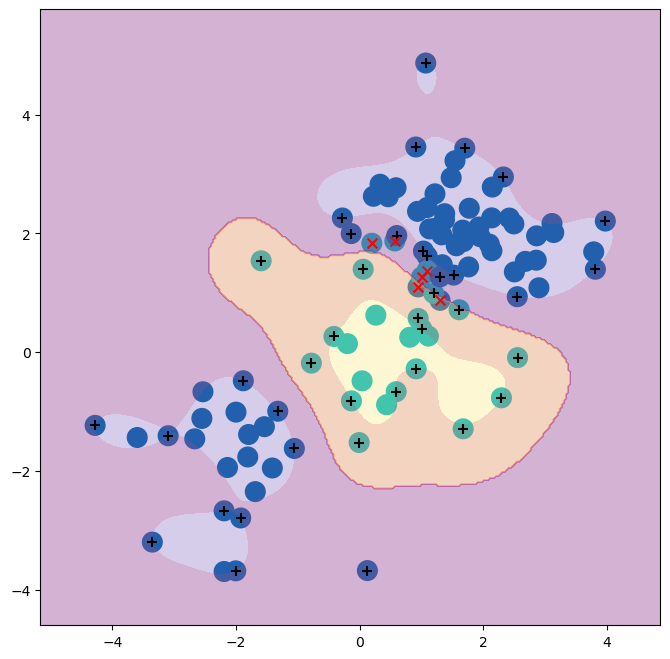

In [26]:
fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         svm_rbf,
         ax=ax)

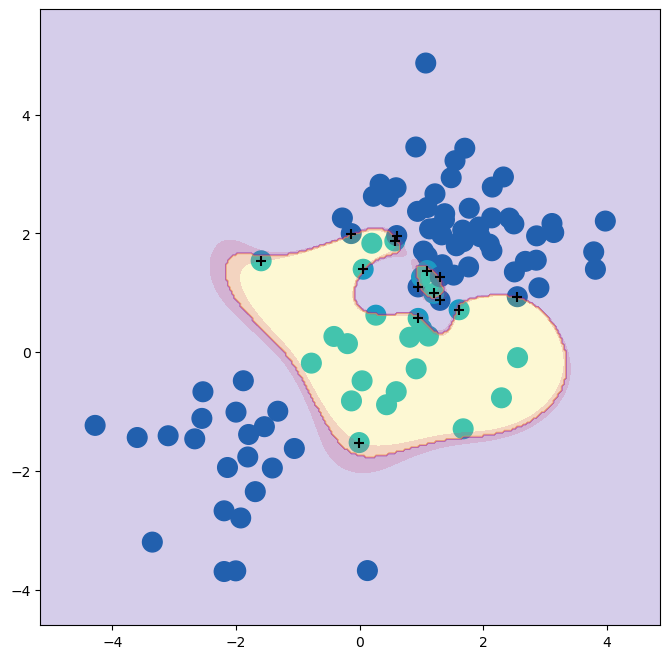

In [28]:
svm_rbf = SVC(kernel="rbf", gamma=1, C=1e5)
svm_rbf.fit(X_train, y_train)
fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         svm_rbf,
         ax=ax)

In [29]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

grid = skm.GridSearchCV(estimator=svm_rbf,
                        param_grid={
                          "C": [0.1, 1, 10, 100, 1000],
                          "gamma": [0.5, 1, 2, 3, 4]
                        },
                        refit=True,
                        cv=kfold,
                        scoring="accuracy")

grid.fit(X_train, y_train)
grid.best_params_

{'C': 1, 'gamma': 0.5}

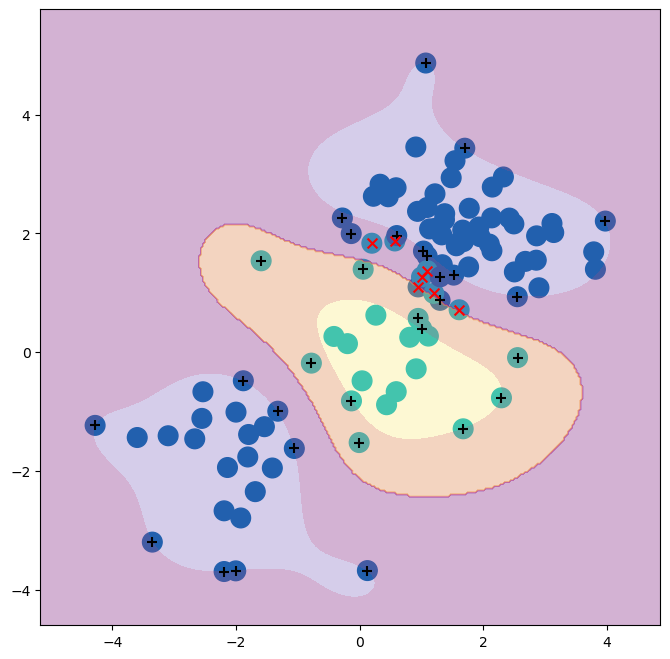

In [30]:
best_svm = grid.best_estimator_
fig, ax = subplots(figsize=(8,8))
plot_svm(X_train,
         y_train,
         best_svm,
         ax=ax)

In [31]:
y_hat_test = best_svm.predict(X_test)
confusion_table(y_hat_test, y_test)

Truth,-1,1
Predicted,,
-1,69,6
1,6,19


### ROC Curves

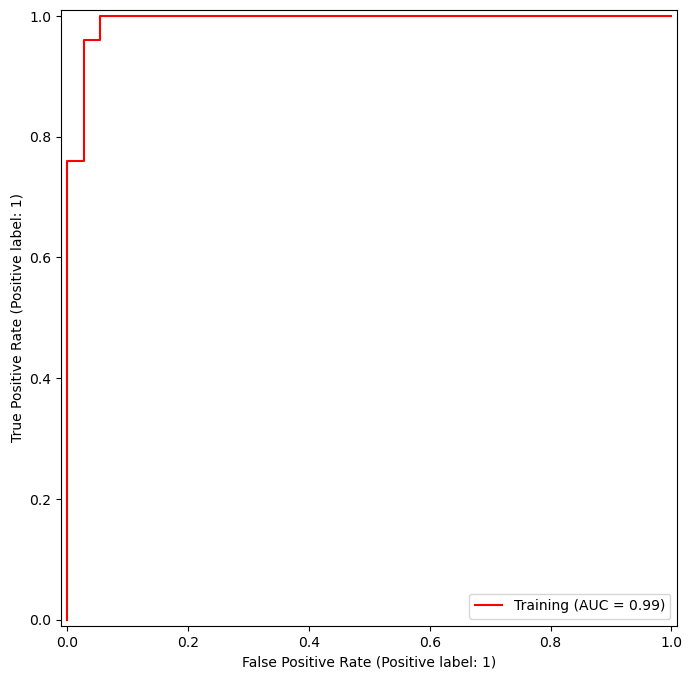

In [32]:
fig, ax = subplots(figsize=(8, 8))
roc_curve(best_svm,
          X_train,
          y_train,
          name="Training",
          color="r",
          ax=ax)

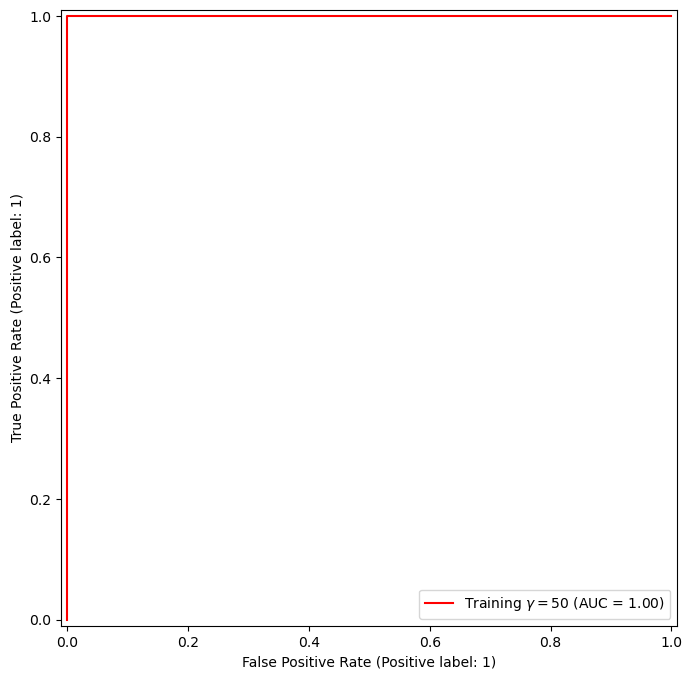

In [33]:
svm_flex = SVC(kernel="rbf", gamma=50, C=1)
svm_flex.fit(X_train, y_train)
fig, ax = subplots(figsize=(8,8))
roc_curve(svm_flex,
          X_train,
          y_train,
          name='Training $\gamma=50$',
          color='r',
          ax=ax)

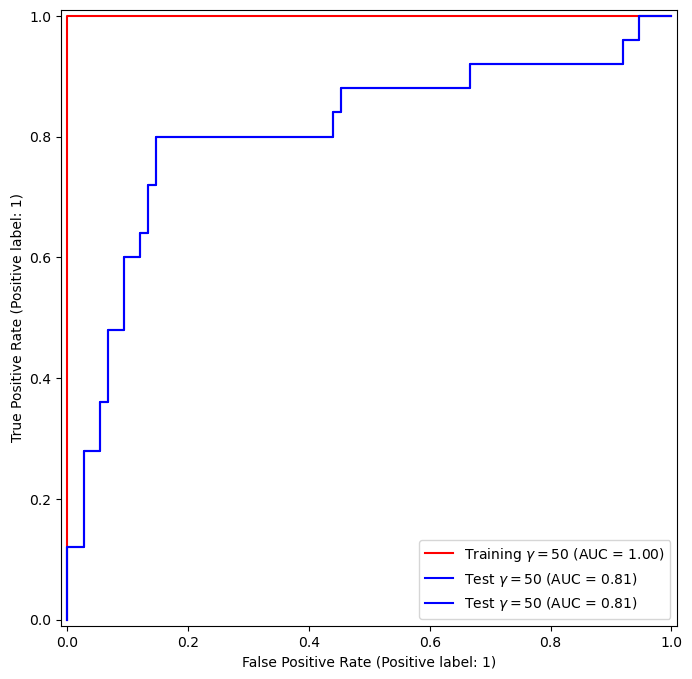

In [35]:
roc_curve(svm_flex,
          X_test,
          y_test,
          name='Test $\gamma=50$',
          color='b',
          ax=ax)
fig

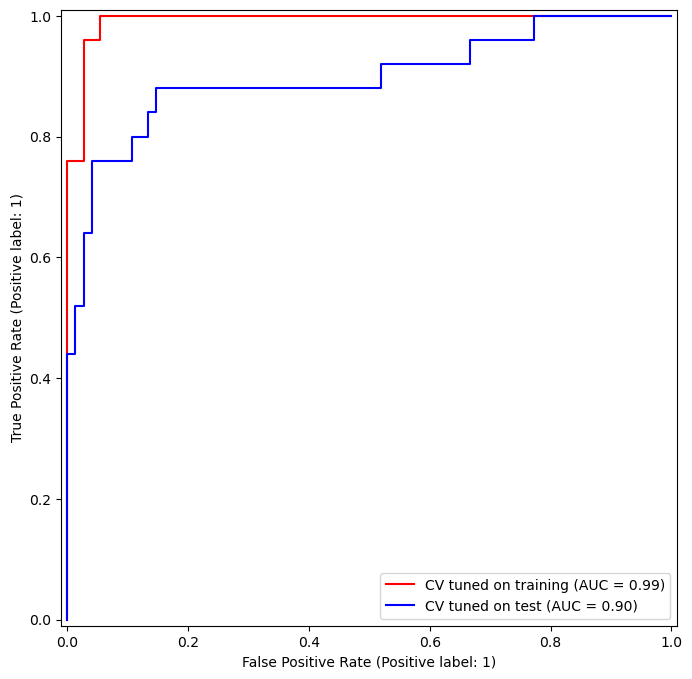

In [36]:
fig, ax = subplots(figsize=(8, 8))
for (X_, y_, c, name) in zip(
  (X_train, X_test),
  (y_train, y_test),
  ("r", "b"),
  ("CV tuned on training",
   "CV tuned on test")
):
  roc_curve(
    best_svm,
    X_,
    y_,
    name=name,
    ax=ax,
    c=c
  )

###  SVM with Multiple Classes

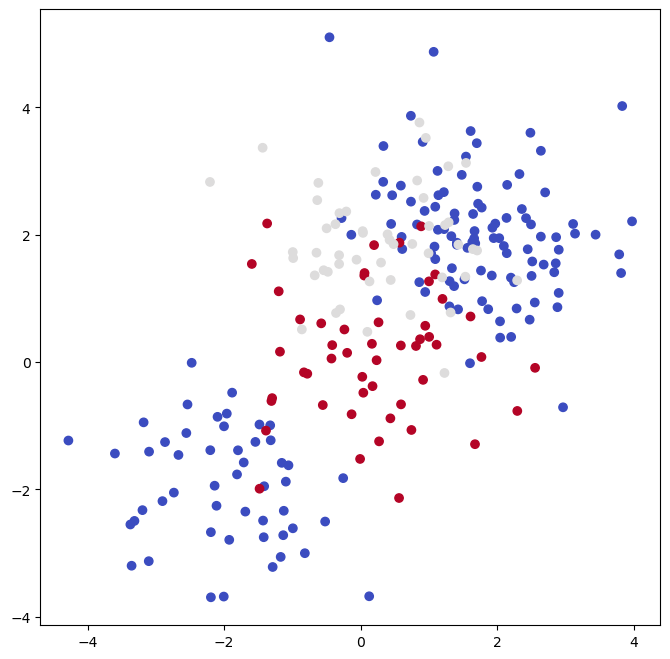

In [37]:
rng = np.random.default_rng(123)
X = np.vstack([X, rng.standard_normal((50, 2))])
y = np.hstack([y, [0]* 50])
X[y==0, 1] += 2
fig, ax = subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cm.coolwarm)

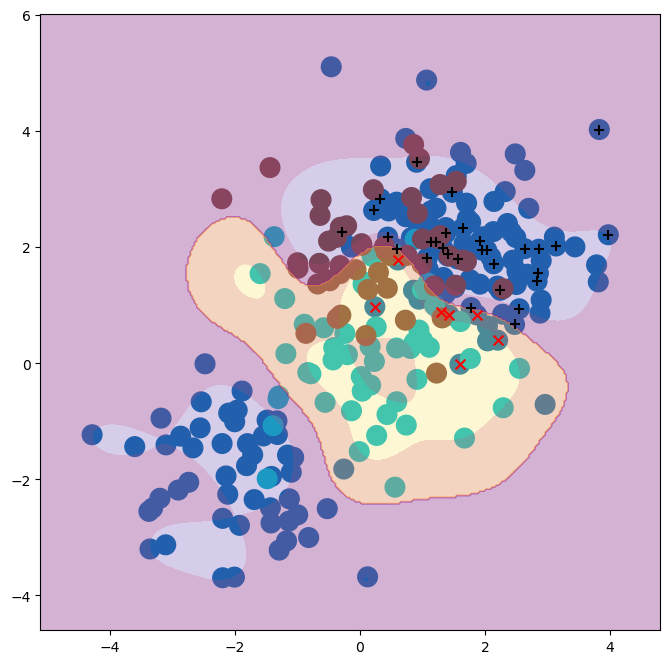

In [38]:
svm_rbf_3 = SVC(kernel="rbf",
                C=10,
                gamma=1,
                decision_function_shape="ovo")

svm_rbf_3.fit(X_train, y_train)
fig, ax = subplots(figsize=(8, 8))
plot_svm(X,
         y,
         svm_rbf_3,
         scatter_cmap=cm.tab10,
         ax=ax)

### Application to Gene Expression Data

In [40]:
Khan = load_data("Khan")
Khan

{'xtest':        G0001     G0002     G0003     G0004     G0005     G0006     G0007  \
 0   0.139501 -1.168927  0.564973 -3.366796 -1.323132 -0.692547  2.327395   
 1   1.164275 -2.018158  1.103533 -2.165435 -1.440117 -0.437420  2.661587   
 2   0.841093  0.254720 -0.208748 -2.148149 -1.512765 -1.263723  2.946642   
 3   0.685065 -1.927579 -0.233068 -1.640413 -1.008954  0.774451  1.617168   
 4  -1.956163 -2.234926  0.281563 -2.695628 -1.214697 -1.059872  2.498070   
 5  -0.258641 -1.684700  0.175800 -2.323809 -1.692276 -0.008637  2.302135   
 6  -1.109875 -1.046969 -0.853786 -2.607752 -1.770781 -1.259133  1.426380   
 7   1.471485 -1.751578 -0.256700 -1.899122 -1.364924 -1.198654  2.489878   
 8  -0.396159 -1.191386  0.696691 -1.862397 -1.312672  0.744980  1.762708   
 9  -2.136224 -2.236797 -0.946492 -2.777400 -1.822631 -0.455233  2.547514   
 10 -0.190676 -1.513219  0.824439 -2.391416 -1.112610  0.591945  2.101032   
 11  1.321409  0.495367  0.041526 -1.541779 -1.627093 -1.184170  2.

In [41]:
Khan["xtrain"].shape, Khan["xtest"].shape

((63, 2308), (20, 2308))

In [43]:
khan_linear = SVC(kernel="linear", C=10)
khan_linear.fit(Khan["xtrain"], Khan["ytrain"])
confusion_table(khan_linear.predict(Khan["xtrain"]), Khan["ytrain"])

Truth,1,2,3,4
Predicted,,,,
1,8,0,0,0
2,0,23,0,0
3,0,0,12,0
4,0,0,0,20


In [45]:
confusion_table(khan_linear.predict(Khan['xtest']), Khan['ytest'])

Truth,1,2,3,4
Predicted,,,,
1,3,0,0,0
2,0,6,2,0
3,0,0,4,0
4,0,0,0,5
